# Clustering Analysis of Syndromes

This notebook performs clustering analysis on syndrome reports data to identify patterns and groups.

In [29]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import ast
import warnings
warnings.filterwarnings('ignore')

# Clustering libraries
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from kmodes.kmodes import KModes
from kmodes.kprototypes import KPrototypes

# For map visualization
import folium
from folium import plugins

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

## Step 1: Import Data

In [30]:
# Load the data
df = pd.read_csv('../data/raw/tmp/reports-gds-unb-2022-2024.csv')

print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {df.columns.tolist()}")
df.head()

Dataset shape: (2067080, 17)

Columns: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms', 'syndrome_id', 'syndrome_description', 'report_country', 'report_state', 'report_city', 'report_street', 'report_reviewed', 'report_traveled_to', 'data_extracted_at']


,report_id,user_id,report_bad_since,report_contact_with_symptom,report_created_at,report_latitude,report_longitude,report_symptoms,syndrome_id,syndrome_description,report_country,report_state,report_city,report_street,report_reviewed,report_traveled_to,data_extracted_at
0,4395232,17369,NaN,NaN,2022-01-01,-15.928432,-47.978894,NaN,NaN,NaN,Brazil,Federal District,Park Way,Estrada Parque Indústria e Abastecimento,NaN,NaN,2025-10-01 23:47:26.379227+00
1,4396655,28693,NaN,NaN,2022-01-01,-10.227293,-44.632727,NaN,NaN,NaN,Brazil,Piauí,Parnaguá,Rua Mario Nogueira,NaN,NaN,2025-10-01 23:47:26.379227+00
2,4394947,6831,NaN,NaN,2022-01-01,-23.229133,-45.916924,NaN,NaN,NaN,Brazil,São Paulo,São José dos Campos,Rua Rogérias,NaN,NaN,2025-10-01 23:47:26.379227+00
3,4394878,20291,NaN,NaN,2022-01-01,-15.992483,-47.993583,NaN,NaN,NaN,Brazil,Federal District,Santa Maria,NaN,NaN,NaN,2025-10-01 23:47:26.379227+00
4,4395320,19069,NaN,NaN,2022-01-01,-17.694863,-48.585805,NaN,NaN,NaN,Brazil,Goiás,Caldas Novas,NaN,NaN,NaN,2025-10-01 23:47:26.379227+00


## Step 2: Data Cleaning and Transformation

In [31]:
# Create a copy for processing
df_clean = df.copy()

# 2.1 - Convert report_id to string
df_clean['report_id'] = df_clean['report_id'].astype(str)

# 2.2 - Convert user_id to string
df_clean['user_id'] = df_clean['user_id'].astype(str)

# 2.3 - report_bad_since (keep as int)

# 2.4 - report_contact_with_symptom (keep as str)

# 2.5 - Convert report_created_at to datetime and format as YYYY-MM-DD
df_clean['report_created_at'] = pd.to_datetime(df_clean['report_created_at']).dt.strftime('%Y-%m-%d')

# 2.6 - report_latitude (keep as float)
df_clean['report_latitude'] = df_clean['report_latitude'].astype(float)

# 2.7 - report_longitude (keep as float)
df_clean['report_longitude'] = df_clean['report_longitude'].astype(float)

# 2.8 - Process report_symptoms: remove "---\n-", keep unique symptoms, create list
def process_symptoms(symptom_str):
    if pd.isna(symptom_str) or symptom_str == '':
        return []
    
    # Try to parse as list if it's already in list format
    try:
        if isinstance(symptom_str, str) and symptom_str.startswith('['):
            symptom_list = ast.literal_eval(symptom_str)
        else:
            symptom_list = [symptom_str]
    except:
        symptom_list = [symptom_str]
    
    # Remove "---\n-" and filter out empty strings
    cleaned_symptoms = []
    for symptom in symptom_list:
        if isinstance(symptom, str):
            symptom = symptom.replace('---\n-', '').strip()
            if symptom and symptom != '':
                cleaned_symptoms.append(symptom)
    
    # Return unique symptoms
    return list(set(cleaned_symptoms))

df_clean['report_symptoms'] = df_clean['report_symptoms'].apply(process_symptoms)

# 2.9 & 2.10 - Drop syndrome_id and syndrome_description
if 'syndrome_id' in df_clean.columns:
    df_clean = df_clean.drop(columns=['syndrome_id'])
if 'syndrome_description' in df_clean.columns:
    df_clean = df_clean.drop(columns=['syndrome_description'])

# 2.11 - report_country (keep as str)

# 2.12 - report_state (keep as str)

# 2.13 - report_city (keep as str)

# 2.14 - report_street (keep as str)

# 2.15 - Drop report_reviewed
if 'report_reviewed' in df_clean.columns:
    df_clean = df_clean.drop(columns=['report_reviewed'])

# 2.16 - report_traveled_to (keep as str)

# 2.17 - Convert data_extracted_at to YYYY-MM-DD format
if 'data_extracted_at' in df_clean.columns:
    df_clean['data_extracted_at'] = pd.to_datetime(df_clean['data_extracted_at']).dt.strftime('%Y-%m-%d')

print("Data cleaning completed!")
print(f"\nFinal shape: {df_clean.shape}")
print(f"\nColumns: {df_clean.columns.tolist()}")
df_clean.head()

Data cleaning completed!

Final shape: (2067080, 14)

Columns: ['report_id', 'user_id', 'report_bad_since', 'report_contact_with_symptom', 'report_created_at', 'report_latitude', 'report_longitude', 'report_symptoms', 'report_country', 'report_state', 'report_city', 'report_street', 'report_traveled_to', 'data_extracted_at']


,report_id,user_id,report_bad_since,report_contact_with_symptom,report_created_at,report_latitude,report_longitude,report_symptoms,report_country,report_state,report_city,report_street,report_traveled_to,data_extracted_at
0,4395232,17369,NaN,NaN,2022-01-01,-15.928432,-47.978894,[],Brazil,Federal District,Park Way,Estrada Parque Indústria e Abastecimento,NaN,2025-10-01
1,4396655,28693,NaN,NaN,2022-01-01,-10.227293,-44.632727,[],Brazil,Piauí,Parnaguá,Rua Mario Nogueira,NaN,2025-10-01
2,4394947,6831,NaN,NaN,2022-01-01,-23.229133,-45.916924,[],Brazil,São Paulo,São José dos Campos,Rua Rogérias,NaN,2025-10-01
3,4394878,20291,NaN,NaN,2022-01-01,-15.992483,-47.993583,[],Brazil,Federal District,Santa Maria,NaN,NaN,2025-10-01
4,4395320,19069,NaN,NaN,2022-01-01,-17.694863,-48.585805,[],Brazil,Goiás,Caldas Novas,NaN,NaN,2025-10-01


## Step 3: Filter and Prepare Data for Clustering

In [32]:
# 3.1 - Filter by date: August 2023 to December 2024
df_clean['report_created_at'] = pd.to_datetime(df_clean['report_created_at'])
df_filtered = df_clean[
    (df_clean['report_created_at'] >= '2023-08-01') & 
    (df_clean['report_created_at'] <= '2024-12-31')
].copy()

print(f"Records after date filter: {len(df_filtered)}")

# 3.2 - Filter only cases with symptoms (non-null and non-empty)
df_filtered = df_filtered[
    df_filtered['report_symptoms'].apply(lambda x: x is not None and len(x) > 0)
].copy()

print(f"Records after symptoms filter: {len(df_filtered)}")

Records after date filter: 980129
Records after symptoms filter: 9628


In [33]:
# 3.3.1 - Create numeric features
# bad_time: difference in days between report_created_at and report_bad_since
# If report_bad_since is already in days (int), use it directly
# Otherwise, calculate the difference
if df_filtered['report_bad_since'].dtype in ['int64', 'float64']:
    # report_bad_since is already in days
    df_filtered['bad_time'] = df_filtered['report_bad_since'].astype(float)
else:
    # report_bad_since is a date, calculate difference
    df_filtered['bad_time'] = (pd.to_datetime(df_filtered['report_created_at']) - 
                               pd.to_datetime(df_filtered['report_bad_since'])).dt.days

# Keep latitude and longitude
numeric_features = ['bad_time', 'report_latitude', 'report_longitude']
df_numeric = df_filtered[numeric_features].copy()

print("Numeric features:")
print(df_numeric.head())
print(f"\nMissing values:\n{df_numeric.isnull().sum()}")

Numeric features:
         bad_time  report_latitude  report_longitude
1087351         0       -15.803070        -48.096974
1087478         0       -15.759996        -47.888892
1087562         0       -15.768863        -47.866190
1087576         0       -15.804472        -47.830550
1087606         0       -15.855856        -48.006736

Missing values:
bad_time            0
report_latitude     0
report_longitude    0
dtype: int64


In [34]:
# 3.3.2 - Prepare categorical features for dummification
# Replace NaN in report_contact_with_symptom with "Não Identificado"
df_filtered['report_contact_with_symptom'] = df_filtered['report_contact_with_symptom'].fillna('Não Identificado')

categorical_features = ['report_contact_with_symptom', 'report_state', 'report_city']
df_categorical = df_filtered[categorical_features].copy()

print("Categorical features:")
print(df_categorical.head())
print(f"\nMissing values:\n{df_categorical.isnull().sum()}")

Categorical features:
        report_contact_with_symptom      report_state report_city
1087351            Não Identificado  Federal District  Taguatinga
1087478            Não Identificado  Federal District    Brasília
1087562            Não Identificado  Federal District    Brasília
1087576            Não Identificado  Federal District    Brasília
1087606            Não Identificado  Federal District  Arniqueira

Missing values:
report_contact_with_symptom       0
report_state                   3653
report_city                    3653
dtype: int64


In [35]:
# 3.3.3 - Process symptoms: create dummy columns for each symptom
# Get all unique symptoms
all_symptoms = set()
for symptom_list in df_filtered['report_symptoms']:
    if isinstance(symptom_list, list):
        all_symptoms.update(symptom_list)

all_symptoms = sorted(list(all_symptoms))
print(f"Total unique symptoms: {len(all_symptoms)}")
print(f"First 20 symptoms: {all_symptoms[:20]}")

# Create dummy columns for symptoms
symptom_dummies = pd.DataFrame(0, index=df_filtered.index, columns=all_symptoms)
for idx, symptom_list in df_filtered['report_symptoms'].items():
    if isinstance(symptom_list, list):
        for symptom in symptom_list:
            if symptom in all_symptoms:
                symptom_dummies.loc[idx, symptom] = 1

print(f"\nSymptoms dummy matrix shape: {symptom_dummies.shape}")
print(f"Total symptom occurrences: {symptom_dummies.sum().sum()}")

Total unique symptoms: 4289
First 20 symptoms: ['Ardênciaecoceiranosolhos', 'Ardênciaecoceiranosolhos\n- Bolhas,espinhasoudescamaçãodapele\n- Coceiranocorpo', 'Ardênciaecoceiranosolhos\n- Bolhas,espinhasoudescamaçãodapele\n- Diarreia\n- Dorabdominal\n- Doratrásdosolhos\n- Dordegarganta\n- Dordecabeça\n- Doresnocorpo\n- Febre\n- Gânglioslinfáticosinchados\n- Manchasvermelhasnocorpo\n- Olhosvermelhoselacrimejantes\n- Sangramentonosolhos,gengivaounariz\n- Sangueoumuconasfezes', 'Ardênciaecoceiranosolhos\n- Bolhas,espinhasoudescamaçãodapele\n- Dordecabeça', 'Ardênciaecoceiranosolhos\n- Coceiranocorpo\n- Coriza\n- Diminuiçãodoapetite\n- Dorabdominal\n- Dordecabeça\n- Doresnocorpo\n- FraquezaouTontura\n- Mal-estar/enjoo\n- Tosse', 'Ardênciaecoceiranosolhos\n- Coceiranocorpo\n- Dordecabeça\n- Dordegarganta', 'Ardênciaecoceiranosolhos\n- Coceiranocorpo\n- Doresnocorpo\n- Dorabdominal', 'Ardênciaecoceiranosolhos\n- Coriza', 'Ardênciaecoceiranosolhos\n- Coriza\n- Coceiranocorpo\n- Diminuiçãodoap

## Step 4: Deduplicate Data by user_id

In [36]:
# Organize data by user_id and report_id, sorted by report_created_at
# Keep original index for tracking
df_dedup = df_filtered[['user_id', 'report_id', 'report_created_at']].copy()
df_dedup['original_index'] = df_dedup.index
df_dedup = df_dedup.sort_values(['user_id', 'report_created_at']).reset_index(drop=True)

# Deduplication logic:
# If same user_id has multiple reports with symptoms on consecutive days, keep only the last day
# If more than 7 days between reports, keep both

def deduplicate_user_reports(group):
    if len(group) == 1:
        return group[['original_index']]
    
    group = group.sort_values('report_created_at').reset_index(drop=True)
    keep_indices = []
    
    for i in range(len(group)):
        if i == 0:
            keep_indices.append(i)
        else:
            prev_date = pd.to_datetime(group.loc[keep_indices[-1], 'report_created_at'])
            curr_date = pd.to_datetime(group.loc[i, 'report_created_at'])
            days_diff = (curr_date - prev_date).days
            
            if days_diff > 7:
                # More than 7 days apart, keep both
                keep_indices.append(i)
            else:
                # Consecutive days, replace previous with current (keep the last one)
                keep_indices[-1] = i
    
    return group.loc[keep_indices, ['original_index']]

# Apply deduplication
df_dedup_result = df_dedup.groupby('user_id').apply(deduplicate_user_reports).reset_index(drop=True)

print(f"Records before deduplication: {len(df_filtered)}")
print(f"Records after deduplication: {len(df_dedup_result)}")

# Get the original indices to keep
keep_indices = df_dedup_result['original_index'].tolist()
df_final = df_filtered.loc[keep_indices].copy()
df_numeric_final = df_numeric.loc[keep_indices].copy()
df_categorical_final = df_categorical.loc[keep_indices].copy()
symptom_dummies_final = symptom_dummies.loc[keep_indices].copy()

print(f"\nFinal dataset size: {len(df_final)}")

Records before deduplication: 9628
Records after deduplication: 5408

Final dataset size: 5408


## Step 5: Prepare and Save Processed Dataset

In [37]:
# Create dummy variables for categorical features
categorical_dummies = pd.get_dummies(df_categorical_final, columns=categorical_features, prefix=categorical_features)

# Combine all features in the specified order:
# user_id, report_created_at, report_id, numeric features, categorical dummies, symptom dummies
df_processed = pd.concat([
    df_final[['user_id', 'report_created_at', 'report_id']].reset_index(drop=True),
    df_numeric_final.reset_index(drop=True),
    categorical_dummies.reset_index(drop=True),
    symptom_dummies_final.reset_index(drop=True)
], axis=1)

print(f"Processed dataset shape: {df_processed.shape}")
print(f"\nColumn order:")
print(df_processed.columns.tolist()[:20])
print("...")
print(f"Total columns: {len(df_processed.columns)}")

# Save to CSV
import os
os.makedirs('../data/processed', exist_ok=True)
df_processed.to_csv('../data/processed/clustering_dataset.csv', index=False)
print("\nDataset saved to ../data/processed/clustering_dataset.csv")

Processed dataset shape: (5408, 4393)

Column order:
['user_id', 'report_created_at', 'report_id', 'bad_time', 'report_latitude', 'report_longitude', 'report_contact_with_symptom_Casa', 'report_contact_with_symptom_Instituição de Ensino', 'report_contact_with_symptom_Local de Trabalho ou Repartição Pública', 'report_contact_with_symptom_Não Identificado', 'report_contact_with_symptom_Supermercado ou Shopping', 'report_state_Amazonas', 'report_state_Andalusia', 'report_state_Autonomous City of Buenos Aires', 'report_state_Bahia', 'report_state_Federal District', 'report_state_Goiás', 'report_state_Mato Grosso do Sul', 'report_state_Minas Gerais', 'report_state_Pernambuco']
...
Total columns: 4393

Dataset saved to ../data/processed/clustering_dataset.csv


## Step 6: Clustering with Multiple Algorithms

In [38]:
# Prepare features for clustering (exclude user_id, report_created_at, report_id)
feature_cols = [col for col in df_processed.columns 
                if col not in ['user_id', 'report_created_at', 'report_id']]
X = df_processed[feature_cols].copy()

# Handle missing values
X = X.fillna(0)

print(f"Feature matrix shape: {X.shape}")
print(f"Missing values: {X.isnull().sum().sum()}")

# Standardize numeric features for algorithms that need it
scaler = StandardScaler()
X_scaled = pd.DataFrame(
    scaler.fit_transform(X),
    columns=X.columns,
    index=X.index
)

Feature matrix shape: (5408, 4390)
Missing values: 0


In [39]:
# Identify numeric and categorical columns for K-Prototypes
numeric_cols = ['bad_time', 'report_latitude', 'report_longitude']
categorical_cols = [col for col in X.columns if col not in numeric_cols]

# Convert to numpy arrays
X_numeric = X[numeric_cols].values
X_categorical = X[categorical_cols].values

print(f"Numeric features shape: {X_numeric.shape}")
print(f"Categorical features shape: {X_categorical.shape}")

Numeric features shape: (5408, 3)
Categorical features shape: (5408, 4387)


In [40]:
# Define parameter grids for each algorithm
n_clusters_range = [3, 4, 5, 6, 7, 8]

# K-Means
kmeans_params = {
    'n_clusters': n_clusters_range,
    'init': ['k-means++', 'random'],
    'n_init': [10],
    'random_state': [42]
}

# Gaussian Mixture Model
gmm_params = {
    'n_components': n_clusters_range,
    'covariance_type': ['full', 'tied', 'diag'],
    'random_state': [42]
}

# Agglomerative Clustering
agg_params = {
    'n_clusters': n_clusters_range,
    'linkage': ['ward', 'complete', 'average']
}

# DBSCAN
dbscan_params = {
    'eps': [0.5, 1.0, 1.5, 2.0, 2.5],
    'min_samples': [5, 10, 15, 20]
}

# K-Prototypes (for mixed data)
kprototypes_params = {
    'n_clusters': n_clusters_range,
    'init': ['Huang', 'Cao', 'random'],
    'n_init': [10],
    'random_state': [42]
}

print("Parameter grids defined for all algorithms")

Parameter grids defined for all algorithms


In [41]:
# Function to evaluate clustering
def evaluate_clustering(X, labels, algorithm_name):
    if len(set(labels)) < 2 or -1 in labels:
        return {
            'silhouette': -1,
            'davies_bouldin': float('inf'),
            'calinski_harabasz': 0,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        }
    
    try:
        silhouette = silhouette_score(X, labels)
        davies_bouldin = davies_bouldin_score(X, labels)
        calinski_harabasz = calinski_harabasz_score(X, labels)
        
        return {
            'silhouette': silhouette,
            'davies_bouldin': davies_bouldin,
            'calinski_harabasz': calinski_harabasz,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        }
    except:
        return {
            'silhouette': -1,
            'davies_bouldin': float('inf'),
            'calinski_harabasz': 0,
            'n_clusters': len(set(labels)) - (1 if -1 in labels else 0)
        }

results = {}

In [42]:
# K-Means Grid Search
print("Running K-Means grid search...")
kmeans_results = []
for params in ParameterGrid(kmeans_params):
    try:
        kmeans = KMeans(**params, max_iter=300)
        labels = kmeans.fit_predict(X_scaled)
        metrics = evaluate_clustering(X_scaled, labels, 'KMeans')
        metrics.update(params)
        kmeans_results.append(metrics)
    except Exception as e:
        print(f"Error with params {params}: {e}")
        continue

kmeans_df = pd.DataFrame(kmeans_results)
best_kmeans = kmeans_df.loc[kmeans_df['silhouette'].idxmax()]
results['KMeans'] = {
    'best_params': best_kmeans.to_dict(),
    'all_results': kmeans_df
}

print(f"Best K-Means - Silhouette: {best_kmeans['silhouette']:.4f}, "
      f"Davies-Bouldin: {best_kmeans['davies_bouldin']:.4f}, "
      f"Clusters: {int(best_kmeans['n_clusters'])}")

Running K-Means grid search...
Best K-Means - Silhouette: 0.2686, Davies-Bouldin: 1.9934, Clusters: 3


In [43]:
# K-Means Grid Search
print("Running K-Means grid search...")
kmeans_results = []
for params in ParameterGrid(kmeans_params):
    try:
        kmeans = KMeans(**params, max_iter=300)
        labels = kmeans.fit_predict(X_scaled)
        metrics = evaluate_clustering(X_scaled, labels, 'KMeans')
        metrics.update(params)
        kmeans_results.append(metrics)
    except Exception as e:
        print(f"Error with params {params}: {e}")
        continue

kmeans_df = pd.DataFrame(kmeans_results)
best_kmeans = kmeans_df.loc[kmeans_df['silhouette'].idxmax()]
results['KMeans'] = {
    'best_params': best_kmeans.to_dict(),
    'all_results': kmeans_df
}

print(f"Best K-Means - Silhouette: {best_kmeans['silhouette']:.4f}, "
      f"Davies-Bouldin: {best_kmeans['davies_bouldin']:.4f}, "
      f"Clusters: {int(best_kmeans['n_clusters'])}")

Running K-Means grid search...
Best K-Means - Silhouette: 0.2686, Davies-Bouldin: 1.9934, Clusters: 3


In [44]:
# Gaussian Mixture Model Grid Search
print("Running GMM grid search...")
gmm_results = []
for params in ParameterGrid(gmm_params):
    try:
        gmm = GaussianMixture(**params, max_iter=100)
        labels = gmm.fit_predict(X_scaled)
        metrics = evaluate_clustering(X_scaled, labels, 'GMM')
        metrics.update(params)
        gmm_results.append(metrics)
    except Exception as e:
        print(f"Error with params {params}: {e}")
        continue

gmm_df = pd.DataFrame(gmm_results)
best_gmm = gmm_df.loc[gmm_df['silhouette'].idxmax()]
results['GMM'] = {
    'best_params': best_gmm.to_dict(),
    'all_results': gmm_df
}

print(f"Best GMM - Silhouette: {best_gmm['silhouette']:.4f}, "
      f"Davies-Bouldin: {best_gmm['davies_bouldin']:.4f}, "
      f"Clusters: {int(best_gmm['n_clusters'])}")

Running GMM grid search...
Best GMM - Silhouette: 0.2686, Davies-Bouldin: 1.9934, Clusters: 3


In [45]:
# DBSCAN Grid Search
print("Running DBSCAN grid search...")
dbscan_results = []
for params in ParameterGrid(dbscan_params):
    try:
        dbscan = DBSCAN(**params)
        labels = dbscan.fit_predict(X_scaled)
        metrics = evaluate_clustering(X_scaled, labels, 'DBSCAN')
        metrics.update(params)
        dbscan_results.append(metrics)
    except Exception as e:
        print(f"Error with params {params}: {e}")
        continue

dbscan_df = pd.DataFrame(dbscan_results)
# Filter out results with too few clusters or too many noise points
dbscan_df_filtered = dbscan_df[
    (dbscan_df['n_clusters'] >= 2) & 
    (dbscan_df['n_clusters'] <= 20)
]
if len(dbscan_df_filtered) > 0:
    best_dbscan = dbscan_df_filtered.loc[dbscan_df_filtered['silhouette'].idxmax()]
else:
    best_dbscan = dbscan_df.loc[dbscan_df['silhouette'].idxmax()]

results['DBSCAN'] = {
    'best_params': best_dbscan.to_dict(),
    'all_results': dbscan_df
}

print(f"Best DBSCAN - Silhouette: {best_dbscan['silhouette']:.4f}, "
      f"Davies-Bouldin: {best_dbscan['davies_bouldin']:.4f}, "
      f"Clusters: {int(best_dbscan['n_clusters'])}")

Running DBSCAN grid search...
Best DBSCAN - Silhouette: -1.0000, Davies-Bouldin: inf, Clusters: 13


In [ ]:
# K-Prototypes Grid Search (for mixed data)
print("Running K-Prototypes grid search...")
kprototypes_results = []
categorical_indices = list(range(len(numeric_cols), len(numeric_cols) + len(categorical_cols)))

for params in list(ParameterGrid(kprototypes_params))[:20]:  # Limit to avoid long runtime
    try:
        kp = KPrototypes(
            n_clusters=params['n_clusters'],
            init=params['init'],
            n_init=params['n_init'],
            random_state=params['random_state']
        )
        # Combine numeric and categorical
        X_mixed = np.hstack([X_numeric, X_categorical.astype(float)])
        labels = kp.fit_predict(X_mixed, categorical=categorical_indices)
        metrics = evaluate_clustering(X_mixed, labels, 'KPrototypes')
        metrics.update(params)
        kprototypes_results.append(metrics)
    except Exception as e:
        print(f"Error with params {params}: {e}")
        continue

if kprototypes_results:
    kp_df = pd.DataFrame(kprototypes_results)
    best_kp = kp_df.loc[kp_df['silhouette'].idxmax()]
    results['KPrototypes'] = {
        'best_params': best_kp.to_dict(),
        'all_results': kp_df
    }
    print(f"Best K-Prototypes - Silhouette: {best_kp['silhouette']:.4f}, "
          f"Davies-Bouldin: {best_kp['davies_bouldin']:.4f}, "
          f"Clusters: {int(best_kp['n_clusters'])}")
else:
    print("K-Prototypes failed to produce results")

Running K-Prototypes grid search...


## Step 7: Analyze Results and Select Best Algorithm

In [ ]:
# Compare all algorithms
comparison = []
for algo_name, algo_results in results.items():
    best = algo_results['best_params']
    comparison.append({
        'Algorithm': algo_name,
        'Silhouette Score': best['silhouette'],
        'Davies-Bouldin Score': best['davies_bouldin'],
        'Calinski-Harabasz Score': best['calinski_harabasz'],
        'Number of Clusters': int(best['n_clusters'])
    })

comparison_df = pd.DataFrame(comparison)
comparison_df = comparison_df.sort_values('Silhouette Score', ascending=False)

print("Algorithm Comparison:")
print(comparison_df.to_string(index=False))

# Select best algorithm: highest silhouette (internal cohesion), lowest Davies-Bouldin (internal separation)
# Higher Calinski-Harabasz is better (separation between clusters)
comparison_df['Combined Score'] = (
    comparison_df['Silhouette Score'] - 
    (comparison_df['Davies-Bouldin Score'] / comparison_df['Davies-Bouldin Score'].max()) +
    (comparison_df['Calinski-Harabasz Score'] / comparison_df['Calinski-Harabasz Score'].max())
)

best_algo_name = comparison_df.loc[comparison_df['Combined Score'].idxmax(), 'Algorithm']
print(f"\nBest Algorithm: {best_algo_name}")
print(f"  Silhouette Score: {comparison_df.loc[comparison_df['Algorithm'] == best_algo_name, 'Silhouette Score'].values[0]:.4f}")
print(f"  Davies-Bouldin Score: {comparison_df.loc[comparison_df['Algorithm'] == best_algo_name, 'Davies-Bouldin Score'].values[0]:.4f}")
# Linha corrigida abaixo:
print(f"  Calinski-Harabasz Score: {comparison_df.loc[comparison_df['Algorithm'] == best_algo_name, 'Calinski-Harabasz Score'].values[0]:.4f}")
# Train the best model and assign cluster labels to df_processed
print(f"\nTraining best model ({best_algo_name}) and assigning cluster labels...")

# Prepare data for clustering - use all feature columns (exclude ID columns)
feature_cols = [col for col in df_processed.columns if col not in ['user_id', 'report_created_at', 'report_id']]
X_scaled = StandardScaler().fit_transform(df_processed[feature_cols])

best_params = results[best_algo_name]['best_params']

if best_algo_name == 'KMeans':
    best_model = KMeans(n_clusters=int(best_params['n_clusters']), random_state=42, n_init=10)
    final_labels = best_model.fit_predict(X_scaled)
elif best_algo_name == 'GMM':
    best_model = GaussianMixture(n_components=int(best_params['n_clusters']), random_state=42)
    final_labels = best_model.fit_predict(X_scaled)
elif best_algo_name == 'DBSCAN':
    best_model = DBSCAN(eps=best_params.get('eps', 0.5), min_samples=best_params.get('min_samples', 5))
    final_labels = best_model.fit_predict(X_scaled)
elif best_algo_name == 'Agglomerative':
    best_model = AgglomerativeClustering(n_clusters=int(best_params['n_clusters']))
    final_labels = best_model.fit_predict(X_scaled)
else:
    # Default to KMeans if algorithm not recognized
    best_model = KMeans(n_clusters=int(best_params['n_clusters']), random_state=42, n_init=10)
    final_labels = best_model.fit_predict(X_scaled)

# Assign cluster labels to df_processed
df_processed['cluster'] = final_labels

print(f"Cluster labels assigned. Number of clusters: {len(set(final_labels))}")
print(f"Cluster distribution:\n{pd.Series(final_labels).value_counts().sort_index()}")

Algorithm Comparison:
  Algorithm  Silhouette Score  Davies-Bouldin Score  Calinski-Harabasz Score  Number of Clusters
KPrototypes          0.878793              0.363841             67779.485065                   3
     KMeans          0.268620              1.993435                 3.465845                   3
        GMM          0.268620              1.993435                 3.465845                   3
     DBSCAN         -1.000000                   inf                 0.000000                  13

Best Algorithm: KPrototypes
  Silhouette Score: 0.8788
  Davies-Bouldin Score: 0.3638
  Calinski-Harabasz Score: 67779.4851

Training best model (KPrototypes) and assigning cluster labels...


Cluster labels assigned. Number of clusters: 3
Cluster distribution:
0       8
1    5399
2       1
Name: count, dtype: int64


## Step 8: Generate Cluster Characteristics

In [ ]:
# Analyze characteristics of each cluster
cluster_characteristics = []

for cluster_id in sorted(set(df_processed['cluster'].unique())):
    if cluster_id == -1:  # Skip noise cluster if present
        continue
    
    cluster_data = df_processed[df_processed['cluster'] == cluster_id]
    
    # Numeric features
    numeric_stats = cluster_data[numeric_cols].describe().T
    
    # Symptoms - most common
    symptom_cols = [col for col in df_processed.columns if col in all_symptoms]
    symptom_freq = cluster_data[symptom_cols].sum().sort_values(ascending=False).head(10).to_dict()
    
    # Contact with symptom
    contact_cols = [col for col in df_processed.columns if 'report_contact_with_symptom' in col]
    contact_stats = cluster_data[contact_cols].sum().sort_values(ascending=False).head(3).to_dict()
    
    # State
    state_cols = [col for col in df_processed.columns if 'report_state' in col]
    state_stats = cluster_data[state_cols].sum().sort_values(ascending=False).head(3).to_dict()
    
    # City
    city_cols = [col for col in df_processed.columns if 'report_city' in col]
    city_stats = cluster_data[city_cols].sum().sort_values(ascending=False).head(3).to_dict()
    
    characteristics = {
        'cluster_id': cluster_id,
        'n_records': len(cluster_data),
        'percentage': len(cluster_data) / len(df_processed) * 100,
        'numeric_features': {
            'bad_time_mean': cluster_data['bad_time'].mean(),
            'bad_time_std': cluster_data['bad_time'].std(),
            'latitude_mean': cluster_data['report_latitude'].mean(),
            'longitude_mean': cluster_data['report_longitude'].mean(),
        },
        'top_symptoms': symptom_freq,
        'top_contact_types': contact_stats,
        'top_states': state_stats,
        'top_cities': city_stats
    }
    
    cluster_characteristics.append(characteristics)

# Display characteristics
for char in cluster_characteristics:
    print(f"\n{'='*60}")
    print(f"CLUSTER {char['cluster_id']}")
    print(f"{'='*60}")
    print(f"Number of records: {char['n_records']} ({char['percentage']:.2f}%)")
    print(f"\nNumeric Features:")
    for key, value in char['numeric_features'].items():
        print(f"  {key}: {value:.4f}")
    print(f"\nTop 10 Symptoms:")
    for symptom, count in list(char['top_symptoms'].items())[:10]:
        print(f"  {symptom}: {count}")
    print(f"\nTop Contact Types:")
    for contact, count in list(char['top_contact_types'].items())[:3]:
        print(f"  {contact}: {count}")
    print(f"\nTop States:")
    for state, count in list(char['top_states'].items())[:3]:
        print(f"  {state}: {count}")
    print(f"\nTop Cities:")
    for city, count in list(char['top_cities'].items())[:3]:
        print(f"  {city}: {count}")


CLUSTER 0
Number of records: 8 (0.15%)

Numeric Features:
  bad_time_mean: 0.0000
  bad_time_std: 0.0000
  latitude_mean: -23.2426
  longitude_mean: -46.4058

Top 10 Symptoms:
  Cansaco: 2
  DordeGarganta: 1
  Coceira
- CongestãoNasal
- Conjuntivite: 1
  CongestãoNasal: 1
  CongestãoNasal
- DificuldadeParaRespirar: 1
  Cansaco
- DorDeEstômago
- Fadiga
- NáuseaOuVômito: 1
  CongestãoNasal
- DordeGarganta: 1
  Diarreia
- Diminuiçãodoapetite
- Dorabdominal
- Febre
- FraquezaouTontura
- Mal-estar/enjoo
- NáuseaeVômitos: 0
  Diarreia
- Diminuiçãodoapetite
- Dorabdominal
- Febre
- Mal-estar/enjoo: 0
  Diarreia
- Diminuiçãodoapetite
- Dorabdominal
- FraquezaouTontura
- Mal-estar/enjoo: 0

Top Contact Types:
  report_contact_with_symptom_Não Identificado: 7
  report_contact_with_symptom_Casa: 1
  report_contact_with_symptom_Instituição de Ensino: 0

Top States:
  report_state_São Paulo: 8
  report_state_Amazonas: 0
  report_state_Andalusia: 0

Top Cities:
  report_city_São Paulo: 3
  report_c

## Step 9: Line Plot - Cluster Counts Over Time

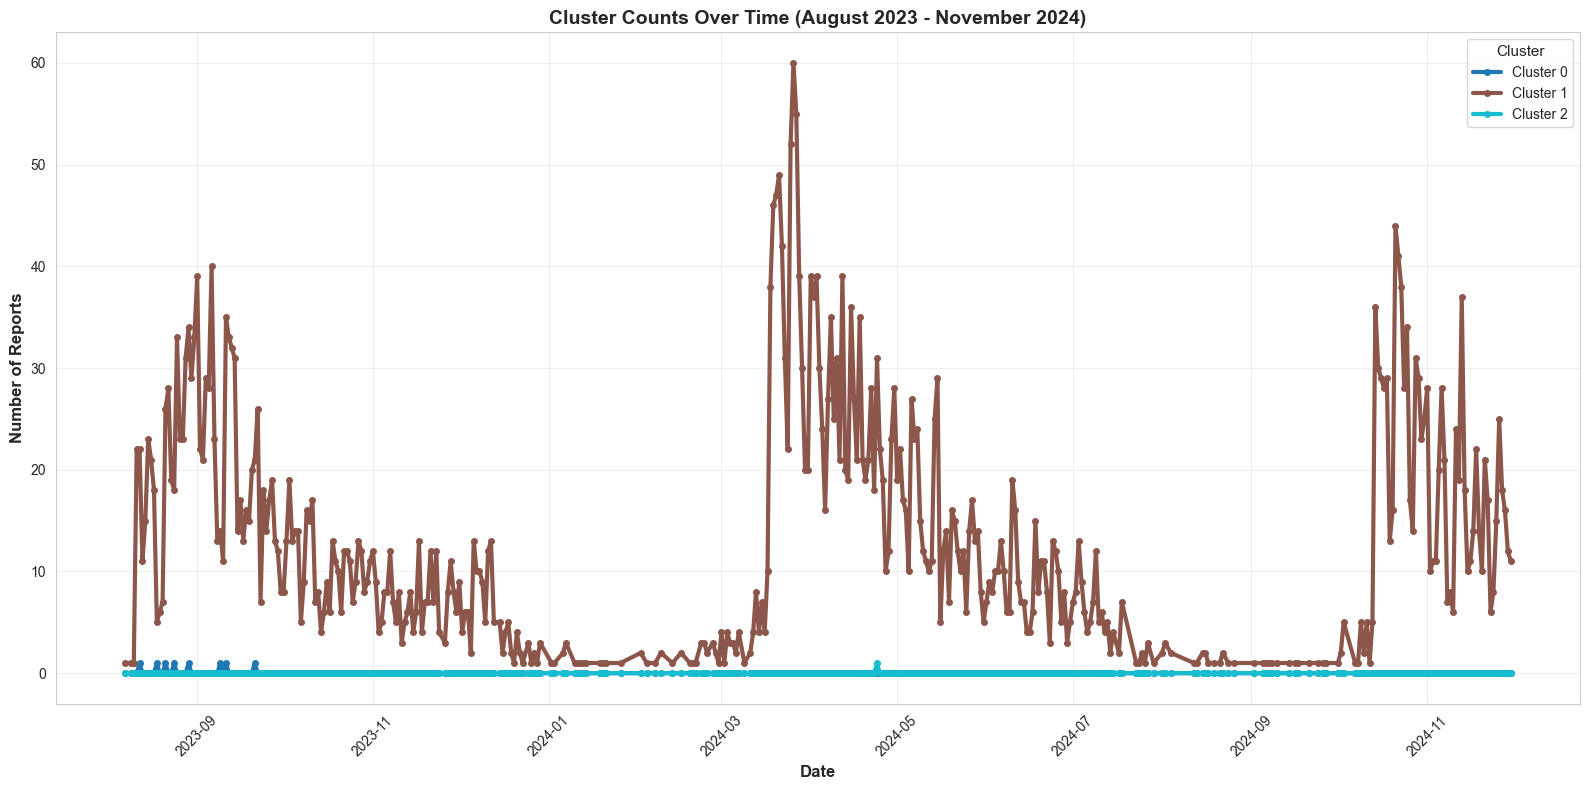

In [ ]:
# Prepare data for time series plot
df_plot = df_processed[['report_created_at', 'cluster']].copy()
df_plot['report_created_at'] = pd.to_datetime(df_plot['report_created_at'])

# Filter to August 2023 - November 2024
df_plot = df_plot[
    (df_plot['report_created_at'] >= '2023-08-01') & 
    (df_plot['report_created_at'] <= '2024-11-30')
]

# Group by date and cluster
df_time_series = df_plot.groupby(['report_created_at', 'cluster']).size().reset_index(name='count')
df_time_series = df_time_series.pivot(index='report_created_at', columns='cluster', values='count').fillna(0)

# Create the plot
plt.figure(figsize=(16, 8))
colors = plt.cm.tab10(np.linspace(0, 1, len(df_time_series.columns)))

for i, cluster_id in enumerate(sorted(df_time_series.columns)):
    if cluster_id == -1:
        continue
    plt.plot(
        df_time_series.index, 
        df_time_series[cluster_id], 
        label=f'Cluster {cluster_id}',
        linewidth=3,
        marker='o',
        markersize=4,
        color=colors[i % len(colors)]
    )

plt.xlabel('Date', fontsize=12, fontweight='bold')
plt.ylabel('Number of Reports', fontsize=12, fontweight='bold')
plt.title('Cluster Counts Over Time (August 2023 - November 2024)', fontsize=14, fontweight='bold')
plt.legend(title='Cluster', fontsize=10, title_fontsize=11)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Step 10: Map Visualization - Clusters by Location

In [ ]:
# Prepare data for map
df_map = df_processed[['report_latitude', 'report_longitude', 'cluster']].copy()

# Remove rows with invalid coordinates
df_map = df_map[
    (df_map['report_latitude'].notna()) & 
    (df_map['report_longitude'].notna()) &
    (df_map['report_latitude'].between(-90, 90)) &
    (df_map['report_longitude'].between(-180, 180))
]

# Calculate center of the map
center_lat = df_map['report_latitude'].mean()
center_lon = df_map['report_longitude'].mean()

# Create base map
m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

# Color palette for clusters
cluster_colors = {
    -1: '#808080',  # Gray for noise
    0: '#1f77b4',
    1: '#ff7f0e',
    2: '#2ca02c',
    3: '#d62728',
    4: '#9467bd',
    5: '#8c564b',
    6: '#e377c2',
    7: '#7f7f7f',
    8: '#bcbd22',
    9: '#17becf'
}

# Add markers for each cluster
for cluster_id in sorted(df_map['cluster'].unique()):
    cluster_data = df_map[df_map['cluster'] == cluster_id]
    color = cluster_colors.get(cluster_id, '#000000')
    
    # Sample data if too many points (for performance)
    if len(cluster_data) > 1000:
        cluster_data = cluster_data.sample(n=1000, random_state=42)
    
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row['report_latitude'], row['report_longitude']],
            radius=3,
            popup=f'Cluster: {cluster_id}',
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.6
        ).add_to(m)

# Add legend
legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: auto; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
     <p><b>Clusters</b></p>
'''
for cluster_id in sorted(df_map['cluster'].unique()):
    color = cluster_colors.get(cluster_id, '#000000')
    count = len(df_map[df_map['cluster'] == cluster_id])
    legend_html += f'<p><i class="fa fa-circle" style="color:{color}"></i> Cluster {cluster_id} ({count})</p>'
legend_html += '</div>'

m.get_root().html.add_child(folium.Element(legend_html))

# Display map
m

# Step 11: Creating cluster dataset

In [ ]:
# Create dataset with clusters and save with current date
from datetime import datetime
import os

# Get current date in YYYY-MM-DD format
current_date = datetime.now().strftime('%Y-%m-%d')

# Create a clean dataset with essential columns and cluster information
# Select key columns from df_processed
df_clusters = df_processed[[
    'user_id',
    'report_id', 
    'report_created_at',
    'cluster',
    'bad_time',
    'report_latitude',
    'report_longitude'
]].copy()

# Add cluster number column (same as cluster, but renamed for clarity)
df_clusters['cluster_number'] = df_clusters['cluster']

# Merge with original data from df_final to get additional information
df_clusters = df_clusters.merge(
    df_final[['report_id', 'report_state', 'report_city', 'report_country', 'report_symptoms']],
    on='report_id',
    how='left'
)

# Reorder columns for better readability
df_clusters = df_clusters[[
    'user_id',
    'report_id',
    'report_created_at',
    'cluster',
    'cluster_number',
    'report_state',
    'report_city',
    'report_country',
    'bad_time',
    'report_latitude',
    'report_longitude',
    'report_symptoms'
]]

# Ensure data/processed directory exists
os.makedirs('../data/processed', exist_ok=True)

# Save dataset with current date
filename = f'../data/processed/{current_date}_clusters_results_dataset.csv'
df_clusters.to_csv(filename, index=False)

print(f"Dataset with clusters saved successfully!")
print(f"File: {filename}")
print(f"Shape: {df_clusters.shape}")
print(f"Columns: {df_clusters.columns.tolist()}")
print(f"\nCluster distribution:")
print(df_clusters['cluster'].value_counts().sort_index())

Dataset with clusters saved successfully!
File: ../data/processed/2026-01-20_clusters_results_dataset.csv
Shape: (5408, 12)
Columns: ['user_id', 'report_id', 'report_created_at', 'cluster', 'cluster_number', 'report_state', 'report_city', 'report_country', 'bad_time', 'report_latitude', 'report_longitude', 'report_symptoms']

Cluster distribution:
cluster
0       8
1    5399
2       1
Name: count, dtype: int64


## Step 12: Clustering com 13 Grupos e Extração de Características

In [ ]:
# Usar DBSCAN que gerou 13 clusters
print("Buscando parâmetros do DBSCAN que geraram 13 clusters...")

# Buscar nos resultados do DBSCAN qual combinação gerou 13 clusters
dbscan_results_df = results['DBSCAN']['all_results']
dbscan_13 = dbscan_results_df[dbscan_results_df['n_clusters'] == 13]

if len(dbscan_13) > 0:
    # Pegar o primeiro resultado com 13 clusters
    dbscan_params_13 = dbscan_13.iloc[0]
    eps_value = dbscan_params_13['eps']
    min_samples_value = int(dbscan_params_13['min_samples'])
    
    print(f"Parâmetros encontrados: eps={eps_value}, min_samples={min_samples_value}")
    
    # Preparar dados para DBSCAN (usar dados escalados)
    feature_cols = [col for col in df_processed.columns if col not in ['user_id', 'report_created_at', 'report_id']]
    X_scaled_13 = StandardScaler().fit_transform(df_processed[feature_cols])
    
    # Treinar DBSCAN com os parâmetros que geram 13 clusters
    dbscan_13_model = DBSCAN(eps=eps_value, min_samples=min_samples_value)
    labels_13 = dbscan_13_model.fit_predict(X_scaled_13)
    
    # Adicionar labels ao dataframe processado
    df_processed_13 = df_processed.copy()
    df_processed_13['cluster_13'] = labels_13
    
    print(f"\nModelo DBSCAN treinado com sucesso!")
    print(f"Número de clusters (excluindo ruído -1): {len(set(labels_13)) - (1 if -1 in labels_13 else 0)}")
    print(f"Pontos de ruído (cluster -1): {sum(labels_13 == -1)}")
    print(f"\nDistribuição dos clusters:")
    cluster_counts = pd.Series(labels_13).value_counts().sort_index()
    print(cluster_counts)
else:
    print("Erro: Não foram encontrados parâmetros do DBSCAN que geraram exatamente 13 clusters.")
    print("Usando parâmetros alternativos...")
    # Tentar encontrar parâmetros próximos
    dbscan_close = dbscan_results_df[dbscan_results_df['n_clusters'].between(10, 15)]
    if len(dbscan_close) > 0:
        dbscan_params_13 = dbscan_close.iloc[0]
        eps_value = dbscan_params_13['eps']
        min_samples_value = int(dbscan_params_13['min_samples'])
        print(f"Usando parâmetros próximos: eps={eps_value}, min_samples={min_samples_value}, n_clusters={int(dbscan_params_13['n_clusters'])}")
        
        feature_cols = [col for col in df_processed.columns if col not in ['user_id', 'report_created_at', 'report_id']]
        X_scaled_13 = StandardScaler().fit_transform(df_processed[feature_cols])
        
        dbscan_13_model = DBSCAN(eps=eps_value, min_samples=min_samples_value)
        labels_13 = dbscan_13_model.fit_predict(X_scaled_13)
        
        df_processed_13 = df_processed.copy()
        df_processed_13['cluster_13'] = labels_13
        
        print(f"\nNúmero de clusters (excluindo ruído): {len(set(labels_13)) - (1 if -1 in labels_13 else 0)}")
        print(f"Pontos de ruído: {sum(labels_13 == -1)}")
        print(f"\nDistribuição dos clusters:")
        print(pd.Series(labels_13).value_counts().sort_index())

Buscando parâmetros do DBSCAN que geraram 13 clusters...
Parâmetros encontrados: eps=0.5, min_samples=20

Modelo DBSCAN treinado com sucesso!
Número de clusters (excluindo ruído -1): 13
Pontos de ruído (cluster -1): 4969

Distribuição dos clusters:
-1     4969
 0       43
 1       33
 2       39
 3       23
 4       58
 5       25
 6       20
 7       33
 8       36
 9       20
 10      41
 11      47
 12      21
Name: count, dtype: int64


In [ ]:
# Extrair características detalhadas dos 13 clusters (excluindo ruído -1 se existir)
print("Extraindo características dos clusters...\n")

cluster_characteristics_13 = []

# Filtrar clusters válidos (excluir -1 que é ruído no DBSCAN)
valid_clusters = sorted([c for c in set(labels_13) if c != -1])
noise_count = sum(labels_13 == -1)

if noise_count > 0:
    print(f"Nota: {noise_count} pontos foram classificados como ruído (cluster -1) e serão excluídos da análise.\n")

for cluster_id in valid_clusters:
    cluster_data = df_processed_13[df_processed_13['cluster_13'] == cluster_id]
    
    # Estatísticas numéricas
    numeric_stats = {
        'bad_time_mean': cluster_data['bad_time'].mean(),
        'bad_time_std': cluster_data['bad_time'].std(),
        'bad_time_min': cluster_data['bad_time'].min(),
        'bad_time_max': cluster_data['bad_time'].max(),
        'latitude_mean': cluster_data['report_latitude'].mean(),
        'latitude_std': cluster_data['report_latitude'].std(),
        'longitude_mean': cluster_data['report_longitude'].mean(),
        'longitude_std': cluster_data['report_longitude'].std(),
    }
    
    # Sintomas mais comuns (top 15)
    symptom_cols = [col for col in df_processed_13.columns if col in all_symptoms]
    symptom_freq = cluster_data[symptom_cols].sum().sort_values(ascending=False)
    top_symptoms = symptom_freq.head(15).to_dict()
    
    # Tipos de contato
    contact_cols = [col for col in df_processed_13.columns if 'report_contact_with_symptom' in col]
    contact_stats = cluster_data[contact_cols].sum().sort_values(ascending=False).to_dict()
    
    # Estados
    state_cols = [col for col in df_processed_13.columns if 'report_state' in col]
    state_stats = cluster_data[state_cols].sum().sort_values(ascending=False).head(5).to_dict()
    
    # Cidades
    city_cols = [col for col in df_processed_13.columns if 'report_city' in col]
    city_stats = cluster_data[city_cols].sum().sort_values(ascending=False).head(5).to_dict()
    
    # Período temporal
    cluster_data['report_created_at'] = pd.to_datetime(cluster_data['report_created_at'])
    date_range = {
        'data_inicio': cluster_data['report_created_at'].min().strftime('%Y-%m-%d'),
        'data_fim': cluster_data['report_created_at'].max().strftime('%Y-%m-%d'),
        'total_dias': (cluster_data['report_created_at'].max() - cluster_data['report_created_at'].min()).days
    }
    
    # Calcular porcentagem excluindo ruído
    total_valid = len(df_processed_13[df_processed_13['cluster_13'] != -1])
    
    characteristics = {
        'cluster_id': cluster_id,
        'n_records': len(cluster_data),
        'percentage': len(cluster_data) / total_valid * 100 if total_valid > 0 else 0,
        **numeric_stats,
        **date_range,
        'top_symptoms': top_symptoms,
        'contact_types': contact_stats,
        'top_states': state_stats,
        'top_cities': city_stats
    }
    
    cluster_characteristics_13.append(characteristics)
    
    # Exibir resumo
    total_valid = len(df_processed_13[df_processed_13['cluster_13'] != -1])
    print(f"{'='*70}")
    print(f"CLUSTER {cluster_id}")
    print(f"{'='*70}")
    print(f"Número de registros: {len(cluster_data)} ({len(cluster_data)/total_valid*100:.2f}%)" if total_valid > 0 else f"Número de registros: {len(cluster_data)}")
    print(f"Período: {date_range['data_inicio']} a {date_range['data_fim']} ({date_range['total_dias']} dias)")
    print(f"\nLocalização média:")
    print(f"  Latitude: {numeric_stats['latitude_mean']:.4f} ± {numeric_stats['latitude_std']:.4f}")
    print(f"  Longitude: {numeric_stats['longitude_mean']:.4f} ± {numeric_stats['longitude_std']:.4f}")
    print(f"\nTop 5 Sintomas:")
    for i, (symptom, count) in enumerate(list(top_symptoms.items())[:5], 1):
        print(f"  {i}. {symptom}: {count} ({count/len(cluster_data)*100:.1f}%)")
    print(f"\nTop 3 Estados:")
    for i, (state, count) in enumerate(list(state_stats.items())[:3], 1):
        state_name = state.replace('report_state_', '')
        print(f"  {i}. {state_name}: {count} ({count/len(cluster_data)*100:.1f}%)")
    print()

Extraindo características dos clusters...

Nota: 4969 pontos foram classificados como ruído (cluster -1) e serão excluídos da análise.

CLUSTER 0
Número de registros: 43 (9.79%)
Período: 2023-08-13 a 2024-05-15 (276 dias)

Localização média:
  Latitude: -15.7794 ± 0.0252
  Longitude: -47.8841 ± 0.0212

Top 5 Sintomas:
  1. Cansaco: 43 (100.0%)
  2. Ardênciaecoceiranosolhos: 0 (0.0%)
  3. Diarreia
- Diminuiçãodoapetite
- Dordecabeça
- Doresnocorpo
- FraquezaouTontura
- Mal-estar/enjoo
- NáuseaeVômitos: 0 (0.0%)
  4. Diarreia
- Diminuiçãodoapetite
- Dorabdominal
- Dordecabeça
- Doresnocorpo
- FraquezaouTontura
- Mal-estar/enjoo: 0 (0.0%)
  5. Diarreia
- Diminuiçãodoapetite
- Dorabdominal
- Dordecabeça
- Doresnocorpo
- Mal-estar/enjoo
- Tosse: 0 (0.0%)

Top 3 Estados:
  1. Federal District: 43 (100.0%)
  2. Amazonas: 0 (0.0%)
  3. Andalusia: 0 (0.0%)

CLUSTER 1
Número de registros: 33 (7.52%)
Período: 2024-05-17 a 2024-10-31 (167 dias)

Localização média:
  Latitude: -15.8348 ± 0.1090
  L

In [ ]:
# Criar DataFrame com características dos clusters para salvar em planilha
cluster_summary_list = []

for char in cluster_characteristics_13:
    # Sintomas como string separada por ponto e vírgula
    symptoms_str = '; '.join([f"{k} ({v})" for k, v in list(char['top_symptoms'].items())[:10]])
    
    # Estados como string
    states_str = '; '.join([f"{k.replace('report_state_', '')} ({v})" for k, v in list(char['top_states'].items())[:5]])
    
    # Cidades como string
    cities_str = '; '.join([f"{k.replace('report_city_', '')} ({v})" for k, v in list(char['top_cities'].items())[:5]])
    
    # Tipos de contato como string
    contacts_str = '; '.join([f"{k.replace('report_contact_with_symptom_', '')} ({v})" for k, v in list(char['contact_types'].items())[:5]])
    
    row = {
        'cluster_id': char['cluster_id'],
        'n_records': char['n_records'],
        'percentage': round(char['percentage'], 2),
        'bad_time_mean': round(char['bad_time_mean'], 2),
        'bad_time_std': round(char['bad_time_std'], 2),
        'latitude_mean': round(char['latitude_mean'], 4),
        'latitude_std': round(char['latitude_std'], 4),
        'longitude_mean': round(char['longitude_mean'], 4),
        'longitude_std': round(char['longitude_std'], 4),
        'data_inicio': char['data_inicio'],
        'data_fim': char['data_fim'],
        'total_dias': char['total_dias'],
        'top_symptoms': symptoms_str,
        'top_states': states_str,
        'top_cities': cities_str,
        'contact_types': contacts_str
    }
    
    cluster_summary_list.append(row)

df_cluster_characteristics = pd.DataFrame(cluster_summary_list)

# Salvar planilha com características dos clusters
from datetime import datetime
import os

current_date = datetime.now().strftime('%Y-%m-%d')
os.makedirs('../data/processed', exist_ok=True)

filename_characteristics = f'../data/processed/{current_date}_cluster_13_characteristics.csv'
df_cluster_characteristics.to_csv(filename_characteristics, index=False, encoding='utf-8-sig')

print(f"\nPlanilha com características dos clusters salva com sucesso!")
print(f"Arquivo: {filename_characteristics}")
print(f"Shape: {df_cluster_characteristics.shape}")
print(f"\nPrimeiras linhas:")
print(df_cluster_characteristics.head())


Planilha com características dos clusters salva com sucesso!
Arquivo: ../data/processed/2026-01-20_cluster_13_characteristics.csv
Shape: (13, 16)

Primeiras linhas:
   cluster_id  n_records  percentage  bad_time_mean  bad_time_std  \
0           0         43        9.79            0.0           0.0   
1           1         33        7.52            0.0           0.0   
2           2         39        8.88            0.0           0.0   
3           3         23        5.24            0.0           0.0   
4           4         58       13.21            0.0           0.0   

   latitude_mean  latitude_std  longitude_mean  longitude_std data_inicio  \
0       -15.7794        0.0252        -47.8841         0.0212  2023-08-13   
1       -15.8348        0.1090        -47.9662         0.1051  2024-05-17   
2       -15.7799        0.0225        -47.8809         0.0179  2023-08-21   
3       -15.8435        0.0959        -47.9634         0.0983  2024-05-26   
4       -15.8279        0.1011    

## Step 13: Mapa com 13 Clusters

In [ ]:
# Preparar dados para mapa com 13 clusters
df_map_13 = df_processed_13[['report_latitude', 'report_longitude', 'cluster_13']].copy()

# Remover linhas com coordenadas inválidas
df_map_13 = df_map_13[
    (df_map_13['report_latitude'].notna()) & 
    (df_map_13['report_longitude'].notna()) &
    (df_map_13['report_latitude'].between(-90, 90)) &
    (df_map_13['report_longitude'].between(-180, 180))
]

# Calcular centro do mapa
center_lat = df_map_13['report_latitude'].mean()
center_lon = df_map_13['report_longitude'].mean()

# Criar mapa base
m_13 = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='OpenStreetMap')

# Paleta de cores para 13 clusters
colors_13 = [
    '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd',
    '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf',
    '#aec7e8', '#ffbb78', '#98df8a'
]

cluster_colors_13 = {i: colors_13[i % len(colors_13)] for i in range(13)}

# Adicionar marcadores para cada cluster (excluir ruído -1 se existir)
valid_clusters_map = sorted([c for c in df_map_13['cluster_13'].unique() if c != -1])

for cluster_id in valid_clusters_map:
    cluster_data = df_map_13[df_map_13['cluster_13'] == cluster_id]
    color = cluster_colors_13.get(cluster_id % 13, '#000000')
    
    # Amostrar dados se houver muitos pontos (para performance)
    if len(cluster_data) > 1000:
        cluster_data = cluster_data.sample(n=1000, random_state=42)
    
    for idx, row in cluster_data.iterrows():
        folium.CircleMarker(
            location=[row['report_latitude'], row['report_longitude']],
            radius=3,
            popup=f'Cluster: {cluster_id}',
            color=color,
            fill=True,
            fillColor=color,
            fillOpacity=0.6
        ).add_to(m_13)

# Adicionar legenda
legend_html_13 = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 250px; height: auto; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:12px; padding: 10px; max-height: 500px; overflow-y: auto;">
     <p><b>Clusters (13 grupos)</b></p>
'''
for cluster_id in valid_clusters_map:
    color = cluster_colors_13.get(cluster_id % 13, '#000000')
    count = len(df_map_13[df_map_13['cluster_13'] == cluster_id])
    percentage = count / len(df_map_13[df_map_13['cluster_13'] != -1]) * 100  # Percentual excluindo ruído
    legend_html_13 += f'<p><i class="fa fa-circle" style="color:{color}"></i> Cluster {cluster_id} ({count} - {percentage:.1f}%)</p>'

# Adicionar informação sobre ruído se existir
noise_count_map = len(df_map_13[df_map_13['cluster_13'] == -1])
if noise_count_map > 0:
    legend_html_13 += f'<p><i class="fa fa-circle" style="color:#808080"></i> Ruído (-1) ({noise_count_map})</p>'
legend_html_13 += '</div>'

m_13.get_root().html.add_child(folium.Element(legend_html_13))

# Salvar mapa
map_filename = f'../data/processed/{current_date}_map_13_clusters.html'
m_13.save(map_filename)

print(f"Mapa criado e salvo com sucesso!")
print(f"Arquivo: {map_filename}")
print(f"\nDistribuição dos clusters no mapa:")
print(df_map_13['cluster_13'].value_counts().sort_index())

# Exibir mapa
m_13

Mapa criado e salvo com sucesso!
Arquivo: ../data/processed/2026-01-20_map_13_clusters.html

Distribuição dos clusters no mapa:
cluster_13
-1     4969
 0       43
 1       33
 2       39
 3       23
 4       58
 5       25
 6       20
 7       33
 8       36
 9       20
 10      41
 11      47
 12      21
Name: count, dtype: int64


In [ ]:
# Salvar também dataset completo com os 13 clusters
df_clusters_13 = df_processed_13[[
    'user_id',
    'report_id', 
    'report_created_at',
    'cluster_13',
    'bad_time',
    'report_latitude',
    'report_longitude'
]].copy()

# Mesclar com dados originais
df_clusters_13 = df_clusters_13.merge(
    df_final[['report_id', 'report_state', 'report_city', 'report_country', 'report_symptoms']],
    on='report_id',
    how='left'
)

# Reordenar colunas
df_clusters_13 = df_clusters_13[[
    'user_id',
    'report_id',
    'report_created_at',
    'cluster_13',
    'report_state',
    'report_city',
    'report_country',
    'bad_time',
    'report_latitude',
    'report_longitude',
    'report_symptoms'
]]

# Salvar dataset completo
filename_clusters_13 = f'../data/processed/{current_date}_clusters_13_dataset.csv'
df_clusters_13.to_csv(filename_clusters_13, index=False, encoding='utf-8-sig')

print(f"Dataset completo com 13 clusters salvo com sucesso!")
print(f"Arquivo: {filename_clusters_13}")
print(f"Shape: {df_clusters_13.shape}")
print(f"\nDistribuição dos clusters:")
print(df_clusters_13['cluster_13'].value_counts().sort_index())

Dataset completo com 13 clusters salvo com sucesso!
Arquivo: ../data/processed/2026-01-20_clusters_13_dataset.csv
Shape: (5408, 11)

Distribuição dos clusters:
cluster_13
-1     4969
 0       43
 1       33
 2       39
 3       23
 4       58
 5       25
 6       20
 7       33
 8       36
 9       20
 10      41
 11      47
 12      21
Name: count, dtype: int64
